In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Medicaldataset.csv')
df.head()


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
df.shape

(1319, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [ ]:
# Missing values per column
print("Missing Value Count:\n", df.isnull().sum())

Missing Value Count:
 Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64


In [ ]:
# Display basic descriptive statistics
display(df.describe())


In [ ]:
# Impute missing values (if present)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median = df[col].median()
        df[col].fillna(median, inplace=True)


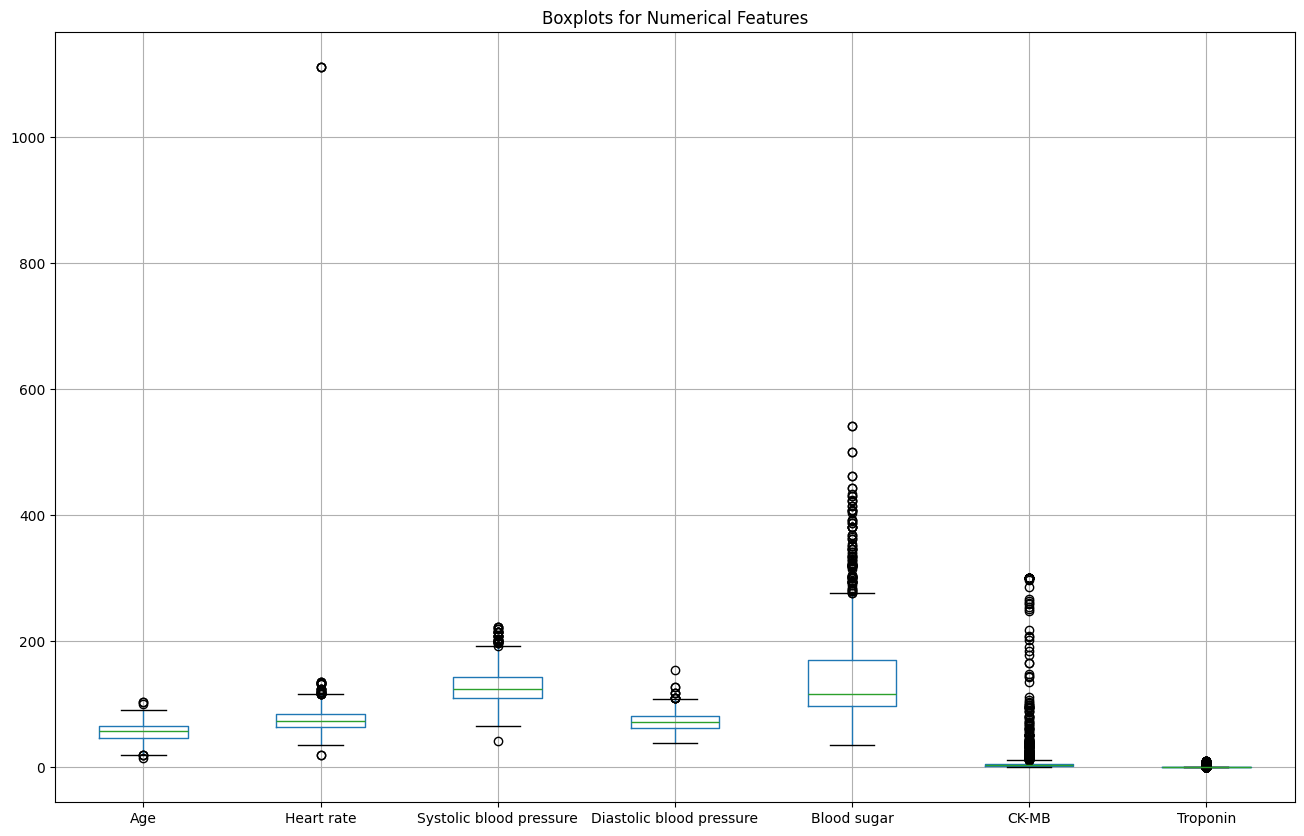

In [ ]:
# Boxplots for numeric columns
numeric_cols = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']
plt.figure(figsize=(16, 10))
df[numeric_cols].boxplot()
plt.title('Boxplots for Numerical Features')
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Medicaldataset.csv to Medicaldataset (1).csv


In [ ]:
# Capping outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


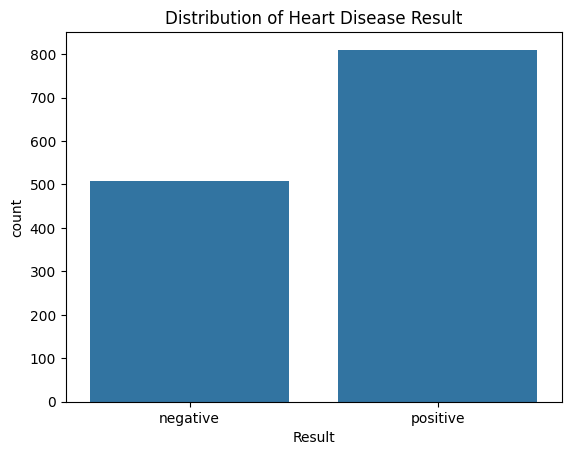

In [ ]:
# Distribution of target
sns.countplot(x='Result', data=df)
plt.title('Distribution of Heart Disease Result')
plt.show()


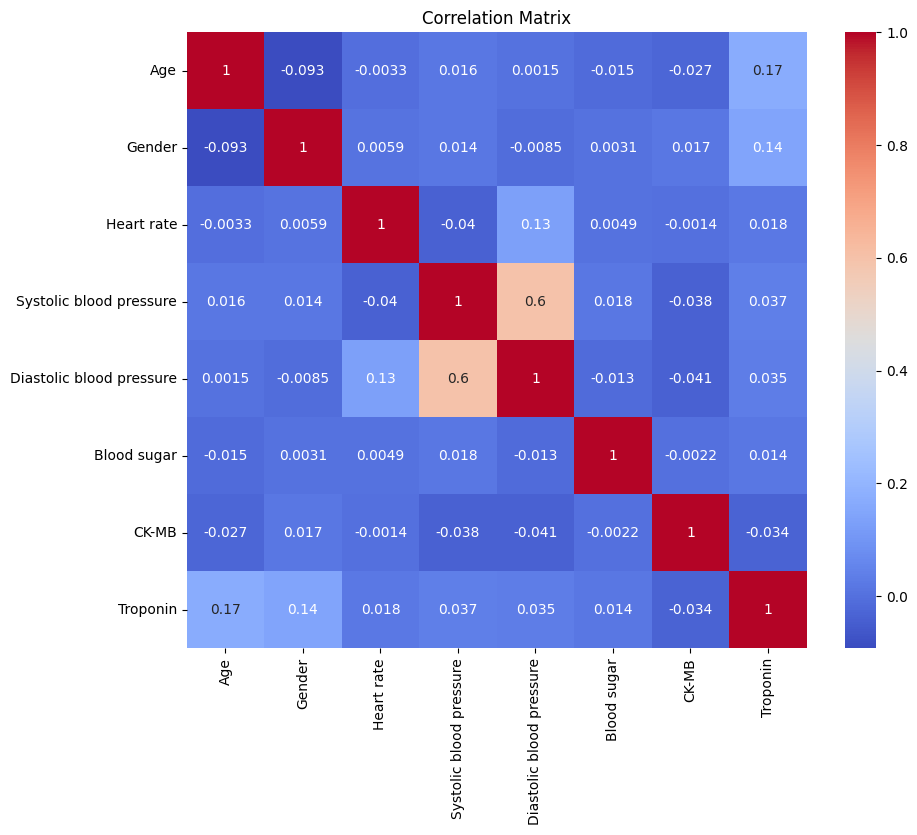

In [ ]:
# Correlation heatmap with numeric columns only
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



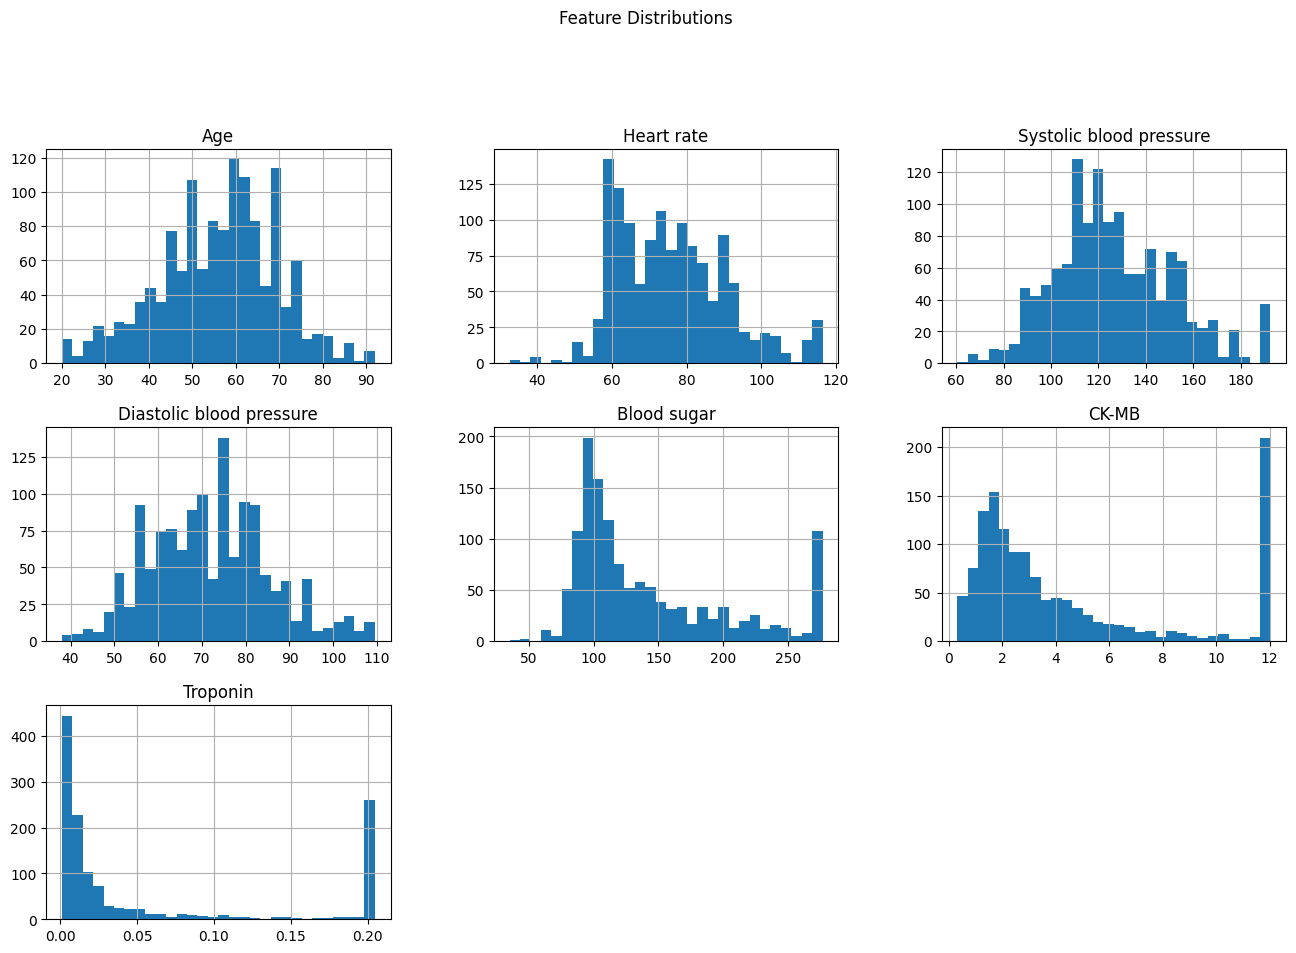

In [ ]:
# Histograms for all features
df[numeric_cols].hist(figsize=(16, 10), bins=30)
plt.suptitle('Feature Distributions', y=1.02)
plt.show()


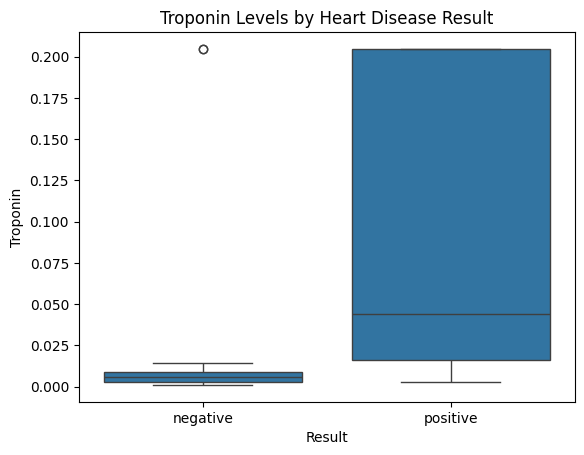

In [ ]:
#Examine relationships (e.g., Troponin vs. disease outcomes).

sns.boxplot(x='Result', y='Troponin', data=df)
plt.title('Troponin Levels by Heart Disease Result')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode 'Gender' if not already numeric
if df['Gender'].dtype == 'O':
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

X = df.drop('Result', axis=1)
y = df['Result']

# Feature scaling (Standardization)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)
print("Train/Test Split:", X_train.shape, X_test.shape)


Train/Test Split: (1055, 8) (264, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (Linear Kernel)': SVC(kernel='linear', probability=True, random_state=42)
}

# Fit all models and store predictions
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"Column {col}")
    print("Value counts:")
    print(df[col].value_counts())
    print("-" *50)

Column Result
Value counts:
Result
positive    810
negative    509
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
#convert "Heart rate" and "Blood sugar" columns to object data type
df = df.astype({'Heart rate': 'object', 'Blood sugar': 'object'})

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1319.0,56.175891,13.559602,20.000,47.000,58.000,65.0000,92.00000
Gender,1319.0,0.659591,0.474027,0.000,0.000,1.000,1.0000,1.00000
Systolic blood pressure,1319.0,126.828658,25.029865,60.500,110.000,124.000,143.0000,192.50000
Diastolic blood pressure,1319.0,72.185747,13.731063,38.000,62.000,72.000,81.0000,109.50000
CK-MB,1319.0,4.463456,3.825702,0.321,1.655,2.850,5.8050,12.03000
Troponin,1319.0,0.058548,0.078493,0.001,0.006,0.014,0.0855,0.20475
